# Goal
Analyze the export performance of semiconductor products (specifically integrated circuits) by destination country to identify high-value markets and trends using trade data.

# Data Loading

| Column                                                 | Description                                                                                         |
| ------------------------------------------------------ | --------------------------------------------------------------------------------------------------- |
| **typeCode**                                           | Type of dataset (e.g., trade data category, usually 'C' for commodity)                              |
| **freqCode**                                           | Frequency of the data (usually annual or monthly)                                                   |
| **refPeriodId**, **refYear**, **refMonth**, **period** | Time indicators — useful for time-series analysis                                                   |
| **reporterCode**, **reporterISO**, **reporterDesc**    | Country that is reporting the trade (e.g., Taiwan)                                                  |
| **flowCode**, **flowDesc**                             | Type of trade: Import or Export                                                                     |
| **partnerCode**, **partnerISO**, **partnerDesc**       | Trade partner (who you're buying from or selling to)                                                |
| **cmdCode**                                            | HS (Harmonized System) commodity code — identifies the product (e.g., 8542 for ICs)                 |
| **cmdDesc**                                            | Product description (e.g., “Electronic integrated circuits”)                                        |
| **qty**, **netWgt**, **grossWgt**                      | Quantity and weight of traded goods (may be True/False if not filled correctly)                     |
| **fobvalue**                                           | **Free On Board** value — cost of goods at point of export (good for export-focused value)          |
| **cifvalue**                                           | **Cost, Insurance, and Freight** — includes shipping/import costs (useful for import-side analysis) |
| **motCode**, **motDesc**                               | Mode of transport (e.g., sea, air)                                                                  |
| **customsCode**, **customsDesc**                       | Customs declaration info                                                                            |
| **qtyUnitCode**, **qtyUnitAbbr**                       | Units of measurement (e.g., kg, pieces)                                                             |
| **isReported**                                         | Whether the data is officially reported (vs. estimated)                                             |

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
pd.reset_option('display.max_rows')

In [21]:
path = '/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly' 
files = [
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataJan25.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataFeb25.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataMar25.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataApr25.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataMay25.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataJune25.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataJan24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataFeb24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataMar24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataApr24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataMay24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataJune24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataJuly24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataAug24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataSep24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataOct24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataNov24.csv",
    "/Users/hbb/Document/Dibimbing---DSDA/Final Project Data Science/data_monthly/TradeDataDec24.csv"
]

# read the first file to lock the schema/order
schema = pd.read_csv(files[0], dtype=str, encoding="latin1", low_memory=False).columns.tolist()

def read_and_fix(fp):
    df = pd.read_csv(fp, dtype=str, encoding="latin1", low_memory=False)
    # ensure same columns/order; create missing as NaN, drop extras
    df = df.reindex(columns=schema)

    # --- FIX: rows shifted left from 'freqCode' onward ---
    # Detect: freqCode should be 'M'/'A'/'Q', NOT 8-digit numbers like 20250101
    mask = df["freqCode"].str.fullmatch(r"\d{8}", na=False)
    if mask.any():
        cols = df.columns.tolist()
        j = cols.index("freqCode")

        bad = df.loc[mask, cols].copy()
        # shift right by 1 from freqCode onward
        bad.iloc[:, j+1:] = bad.iloc[:, j:-1].values
        # set correct freqCode
        bad.iloc[:, j] = "M"

        # (Optional) sanity fill for first 6 fields if you want to be extra-safe
        # If refPeriodId is now 8-digit, derive year/month/period just in case
        rpid = bad["refPeriodId"].str.extract(r"(\d{8})", expand=False)
        ok = rpid.notna()
        bad.loc[ok, "refYear"]  = rpid[ok].str.slice(0, 4)
        bad.loc[ok, "refMonth"] = rpid[ok].str.slice(4, 6).astype(int).astype(str)
        bad.loc[ok, "period"]   = (bad.loc[ok, "refYear"].astype(int)*100 + bad.loc[ok, "refMonth"].astype(int)).astype(str)

        df.loc[mask, cols] = bad.values

    return df

dfs = [read_and_fix(f) for f in files]
merged = pd.concat(dfs, ignore_index=True)

# quick sanity check (should show C, M, 8-digit refPeriodId, 4-digit year, 1-12 month, YYYYMM period)
print(merged.iloc[0][["typeCode","freqCode","refPeriodId","refYear","refMonth","period"]])

#merged.to_csv("merged_fixed.csv", index=False, encoding="utf-8")

typeCode              M
freqCode              M
refPeriodId    20250101
refYear            2025
refMonth              1
period           202501
Name: 0, dtype: object


In [22]:
merged

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,1289.771,1289.771,0,false,true
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,2085.918,2085.918,0,false,true
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,25975646838.107,25975646838.107,0,false,true
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,379.71,379.71,0,false,true
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,9.133,false,NaN,7397398.731,7397398.731,0,false,true
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563566,M,M,20241201,2024,12,202412,842,USA,USA,X,...,NaN,false,0,false,NaN,4246790915,4246790915,0,false,true
563567,M,M,20241201,2024,12,202412,854,BFA,Burkina Faso,M,...,1169,false,0,false,103169.761,NaN,103169.761,0,false,true
563568,M,M,20241201,2024,12,202412,854,BFA,Burkina Faso,X,...,6,false,0,false,NaN,159.747,159.747,0,false,true
563569,M,M,20241201,2024,12,202412,860,UZB,Uzbekistan,M,...,NaN,false,0,false,1268610.99,NaN,1268610.99,2,false,true


In [23]:
df = merged
df

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,1289.771,1289.771,0,false,true
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,2085.918,2085.918,0,false,true
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,25975646838.107,25975646838.107,0,false,true
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,379.71,379.71,0,false,true
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,9.133,false,NaN,7397398.731,7397398.731,0,false,true
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563566,M,M,20241201,2024,12,202412,842,USA,USA,X,...,NaN,false,0,false,NaN,4246790915,4246790915,0,false,true
563567,M,M,20241201,2024,12,202412,854,BFA,Burkina Faso,M,...,1169,false,0,false,103169.761,NaN,103169.761,0,false,true
563568,M,M,20241201,2024,12,202412,854,BFA,Burkina Faso,X,...,6,false,0,false,NaN,159.747,159.747,0,false,true
563569,M,M,20241201,2024,12,202412,860,UZB,Uzbekistan,M,...,NaN,false,0,false,1268610.99,NaN,1268610.99,2,false,true


In [ ]:
def add_month_encoding(d, start="2024-01", end="2025-06"):
    """
    Adds:
      - month_code: YYYYMM as Int64 (e.g., 202501)
      - month_label: 'YYYY-MM'
      - ref_date: Timestamp at month start
    Filters rows to the inclusive [start, end] window.
    """
    d = d.copy()
    d["refYear"]  = pd.to_numeric(d.get("refYear"), errors="coerce")
    d["refMonth"] = pd.to_numeric(d.get("refMonth"), errors="coerce")

    # Fill missing year/month from 'period' (YYYYMM) if available
    if "period" in d.columns:
        per = pd.to_numeric(d["period"].astype(str).str.extract(r"(\d{6})")[0], errors="coerce")
        d.loc[d["refYear"].isna()  & per.notna(), "refYear"]  = per // 100
        d.loc[d["refMonth"].isna() & per.notna(), "refMonth"] = per % 100

    # Build month keys (do NOT group by refMonth alone)
    y = d["refYear"].astype("Int64")
    m = d["refMonth"].astype("Int64")
    d["month_code"]  = y * 100 + m
    d["month_label"] = y.astype(str) + "-" + m.astype(str).str.zfill(2)
    d["ref_date"]    = pd.to_datetime(d["month_label"] + "-01", errors="coerce")

    # Keep only the window you’re analyzing (e.g., 2024-01 .. 2025-06)
    s = pd.to_datetime(f"{start}-01")
    e = pd.to_datetime(f"{end}-01")
    d = d[(d["ref_date"] >= s) & (d["ref_date"] <= e)]

    return d

In [ ]:
df = add_month_encoding(df, start="2024-01", end="2025-06")  # <- single call
ic

# Data Understanding

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 563571 entries, 0 to 563570
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   typeCode                  563571 non-null  object
 1   freqCode                  563571 non-null  object
 2   refPeriodId               563571 non-null  object
 3   refYear                   563571 non-null  object
 4   refMonth                  563571 non-null  object
 5   period                    563571 non-null  object
 6   reporterCode              563571 non-null  object
 7   reporterISO               563571 non-null  object
 8   reporterDesc              563571 non-null  object
 9   flowCode                  563571 non-null  object
 10  flowDesc                  563571 non-null  object
 11  partnerCode               563571 non-null  object
 12  partnerISO                563571 non-null  object
 13  partnerDesc               563571 non-null  object
 14  part

We have 47 tables, but not all of them is useful

In [25]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

typeCode: 1 unique values
freqCode: 1 unique values
refPeriodId: 18 unique values
refYear: 2 unique values
refMonth: 12 unique values
period: 18 unique values
reporterCode: 100 unique values
reporterISO: 100 unique values
reporterDesc: 100 unique values
flowCode: 2 unique values
flowDesc: 2 unique values
partnerCode: 244 unique values
partnerISO: 243 unique values
partnerDesc: 244 unique values
partner2Code: 241 unique values
partner2ISO: 241 unique values
partner2Desc: 241 unique values
classificationCode: 4 unique values
classificationSearchCode: 1 unique values
isOriginalClassification: 1 unique values
cmdCode: 2 unique values
cmdDesc: 2 unique values
aggrLevel: 2 unique values
isLeaf: 1 unique values
customsCode: 1 unique values
customsDesc: 1 unique values
mosCode: 1 unique values
motCode: 1 unique values
motDesc: 1 unique values
qtyUnitCode: 3 unique values
qtyUnitAbbr: 2 unique values
qty: 9959 unique values
isQtyEstimated: 2 unique values
altQtyUnitCode: 4 unique values
altQtyU

In [26]:
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].unique())
    print(df[col].nunique())
    print("-" * 40)

Column: typeCode
['M']
1
----------------------------------------
Column: freqCode
['M']
1
----------------------------------------
Column: refPeriodId
['20250101' '20250201' '20250301' '20250401' '20250501' '20250601'
 '20240101' '20240201' '20240301' '20240401' '20240501' '20240601'
 '20240701' '20240801' '20240901' '20241001' '20241101' '20241201']
18
----------------------------------------
Column: refYear
['2025' '2024']
2
----------------------------------------
Column: refMonth
['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12']
12
----------------------------------------
Column: period
['202501' '202502' '202503' '202504' '202505' '202506' '202401' '202402'
 '202403' '202404' '202405' '202406' '202407' '202408' '202409' '202410'
 '202411' '202412']
18
----------------------------------------
Column: reporterCode
['36' '100' '70' '76' '51' '56' '32' '31' '84' '28' '52' '68' '191' '208'
 '124' '203' '152' '246' '234' '268' '233' '222' '242' '276' '300' '328'
 '344' '308' '320' '

(reportercode, reporterdesc, partnercode, partnerdesc, refYear, refMonth, flowcode, flowdesc, cmdCode, cmdDesc, fobvalue, cifvalue, netWgt, grossWgt) Apparently these are the tables that is necessary for this analysis. First, need to copy the original data.

In [27]:
df_copy = df.copy()

In [28]:
df_copy

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,1289.771,1289.771,0,false,true
1,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,2085.918,2085.918,0,false,true
2,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,25975646838.107,25975646838.107,0,false,true
3,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,0,false,NaN,379.71,379.71,0,false,true
4,M,M,20250101,2025,1,202501,36,AUS,Australia,X,...,NaN,false,9.133,false,NaN,7397398.731,7397398.731,0,false,true
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563566,M,M,20241201,2024,12,202412,842,USA,USA,X,...,NaN,false,0,false,NaN,4246790915,4246790915,0,false,true
563567,M,M,20241201,2024,12,202412,854,BFA,Burkina Faso,M,...,1169,false,0,false,103169.761,NaN,103169.761,0,false,true
563568,M,M,20241201,2024,12,202412,854,BFA,Burkina Faso,X,...,6,false,0,false,NaN,159.747,159.747,0,false,true
563569,M,M,20241201,2024,12,202412,860,UZB,Uzbekistan,M,...,NaN,false,0,false,1268610.99,NaN,1268610.99,2,false,true


In [29]:
# Keep only the necessary columns for analysis
columns_to_keep = [
    'reporterCode', 'reporterDesc', 'partnerCode', 'partnerDesc',
    'period', 'flowCode', 'flowDesc',
    'cmdCode', 'cmdDesc', 'qty', 'fobvalue', 'cifvalue', 'netWgt', 'grossWgt', 'primaryValue'
]
df_copy = df_copy[columns_to_keep]
df_copy.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,NaN,NaN,0,1289.771
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,NaN,NaN,0,2085.918
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,NaN,NaN,0,25975646838.107
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,NaN,NaN,0,379.71
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,NaN,NaN,9.133,7397398.731


In [30]:
# Split export data
df_copy_export = df_copy[df_copy['flowDesc'] == 'Export']

# Split import data
df_copy_import = df_copy[df_copy['flowDesc'] == 'Import']


In [31]:
df_copy_export.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,NaN,NaN,0,1289.771
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,NaN,NaN,0,2085.918
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,NaN,NaN,0,25975646838.107
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,NaN,NaN,0,379.71
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,NaN,NaN,9.133,7397398.731


In [32]:
df_copy_import.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
231,36,Australia,703,Slovakia,202501,M,Import,8542,Electronic integrated circuits,5389,9306.847,9385.708,5.744,0.004,9385.708
232,36,Australia,56,Belgium,202501,M,Import,8542,Electronic integrated circuits,4,666.323,725.776,0.39,0.001,725.776
233,36,Australia,504,Morocco,202501,M,Import,8542,Electronic integrated circuits,25025,8280.091,8568.74,5.062,0,8568.74
234,36,Australia,372,Ireland,202501,M,Import,8542,Electronic integrated circuits,20,1637.654,1736.472,0.934,0,1736.472
235,36,Australia,710,South Africa,202501,M,Import,8542,Electronic integrated circuits,60,1993.038,2012.715,1.232,0,2012.715


# Data Cleaning (Handling Missing Values)

## Export

In [33]:
df_copy_export.describe()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
count,139808,139808,139808,139808,139808,139808,139808,139808,139808,139808,139808,15,134451,139808,139808
unique,94,94,244,244,18,1,1,2,2,2960,110024,15,7987,534,110024
top,642,Romania,0,World,202502,X,Export,TOTAL,All Commodities,0,1.002,251.036,0,0,1.002
freq,20528,20528,10584,10584,26421,139808,139808,116069,116069,133121,105,1,114785,139133,105


In [34]:
df_copy_export.info()

<class 'pandas.core.frame.DataFrame'>
Index: 139808 entries, 0 to 563570
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   reporterCode  139808 non-null  object
 1   reporterDesc  139808 non-null  object
 2   partnerCode   139808 non-null  object
 3   partnerDesc   139808 non-null  object
 4   period        139808 non-null  object
 5   flowCode      139808 non-null  object
 6   flowDesc      139808 non-null  object
 7   cmdCode       139808 non-null  object
 8   cmdDesc       139808 non-null  object
 9   qty           139808 non-null  object
 10  fobvalue      139808 non-null  object
 11  cifvalue      15 non-null      object
 12  netWgt        134451 non-null  object
 13  grossWgt      139808 non-null  object
 14  primaryValue  139808 non-null  object
dtypes: object(15)
memory usage: 17.1+ MB


In [35]:
df_copy_export.isnull().sum()

reporterCode         0
reporterDesc         0
partnerCode          0
partnerDesc          0
period               0
flowCode             0
flowDesc             0
cmdCode              0
cmdDesc              0
qty                  0
fobvalue             0
cifvalue        139793
netWgt            5357
grossWgt             0
primaryValue         0
dtype: int64

In [36]:
df_copy_export[df_copy_export.isna().any(axis=1)]

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,NaN,NaN,0,1289.771
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,NaN,NaN,0,2085.918
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,NaN,NaN,0,25975646838.107
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,NaN,NaN,0,379.71
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,NaN,NaN,9.133,7397398.731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
563562,818,Egypt,0,World,202412,X,Export,8542,Electronic integrated circuits,0,691226.639,NaN,NaN,0,691226.639
563564,826,United Kingdom,0,World,202412,X,Export,8542,Electronic integrated circuits,0,81000424.673,NaN,163418.317,0,81000424.673
563566,842,USA,0,World,202412,X,Export,8542,Electronic integrated circuits,0,4246790915,NaN,NaN,0,4246790915
563568,854,Burkina Faso,0,World,202412,X,Export,8542,Electronic integrated circuits,0,159.747,NaN,6,0,159.747


In [37]:
check = df_copy_export[df_copy_export['netWgt'].isna()]
check.sample(10)

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
211921,124,Canada,428,Latvia,202503,X,Export,8542,Electronic integrated circuits,21,11619.967,NaN,NaN,0,11619.967
229809,242,Fiji,0,World,202503,X,Export,8542,Electronic integrated circuits,54,15786.034,NaN,NaN,0,15786.034
417090,124,Canada,251,France,202505,X,Export,8542,Electronic integrated circuits,0,495190.073,NaN,NaN,0,495190.073
89037,710,South Africa,344,"China, Hong Kong SAR",202501,X,Export,8542,Electronic integrated circuits,0,5480.472,NaN,NaN,0,5480.472
138767,344,"China, Hong Kong SAR",804,Ukraine,202502,X,Export,8542,Electronic integrated circuits,7864000,1945400.638,NaN,NaN,0,1945400.638
211976,124,Canada,608,Philippines,202503,X,Export,8542,Electronic integrated circuits,1,7492.911,NaN,NaN,0,7492.911
244374,392,Japan,446,"China, Macao SAR",202503,X,Export,8542,Electronic integrated circuits,9419,184407.407,NaN,NaN,0,184407.407
542629,710,South Africa,748,Eswatini,202506,X,Export,8542,Electronic integrated circuits,0,3016.936,NaN,NaN,0,3016.936
419628,124,Canada,428,Latvia,202505,X,Export,8542,Electronic integrated circuits,842,26042.912,NaN,NaN,0,26042.912
542620,710,South Africa,842,USA,202506,X,Export,8542,Electronic integrated circuits,0,106256.808,NaN,NaN,0,106256.808


In [38]:
# Calculate and display the percentage of missing values for each column in df_copy
percent_missing = df_copy_export.isna().mean() * 100
print(percent_missing)

reporterCode     0.000000
reporterDesc     0.000000
partnerCode      0.000000
partnerDesc      0.000000
period           0.000000
flowCode         0.000000
flowDesc         0.000000
cmdCode          0.000000
cmdDesc          0.000000
qty              0.000000
fobvalue         0.000000
cifvalue        99.989271
netWgt           3.831683
grossWgt         0.000000
primaryValue     0.000000
dtype: float64


we don't need 'cifvalue' in here. ('fobvalue' is a cost of goods at point of export, while 'cifvalue' is a shipping/import costs).

In [39]:
# Check for zero values in selected columns of df_copy_export
zero_counts = df_copy_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
cifvalue        0
netWgt          0
grossWgt        0
primaryValue    0
dtype: int64


In [40]:
# Convert 'netWgt' to numeric, coerce errors to NaN
df_copy_export['netWgt'] = pd.to_numeric(df_copy_export['netWgt'], errors='coerce')

# Fill missing values in 'netWgt' with the mean of the column
mean_netWgt = df_copy_export['netWgt'].mean()
df_copy_export['netWgt'] = df_copy_export['netWgt'].fillna(mean_netWgt)
df_copy_export['netWgt'] = df_copy_export['netWgt'].replace(0, mean_netWgt)

/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_61213/1051301107.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['netWgt'] = pd.to_numeric(df_copy_export['netWgt'], errors='coerce')
/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_61213/1051301107.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_export['netWgt'] = df_copy_export['netWgt'].fillna(mean_netWgt)
/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_61213/1051301107.py:7: SettingWithCopyWar

In [41]:
df_export = df_copy_export.drop(columns=['cifvalue'])

In [42]:
# check again
percent_missing_check = df_export.isna().mean() * 100
percent_missing_check

reporterCode    0.0
reporterDesc    0.0
partnerCode     0.0
partnerDesc     0.0
period          0.0
flowCode        0.0
flowDesc        0.0
cmdCode         0.0
cmdDesc         0.0
qty             0.0
fobvalue        0.0
netWgt          0.0
grossWgt        0.0
primaryValue    0.0
dtype: float64

In [43]:
#check again
zero_counts = df_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
netWgt          0
grossWgt        0
primaryValue    0
dtype: int64


Since we use 'netWgt' the most, we will drop the 'grossWgt' and 'primaryvalue'

In [44]:
df_export.drop(columns=['grossWgt', 'primaryValue'], inplace=True)

In [45]:
df_export = df_export.reset_index(drop=True)
df_export.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,2318.376691
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,2318.376691
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,2318.376691
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,2318.376691
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,2318.376691


In [46]:
# Check rows where reporterCode is 0 in the check DataFrame
df_export[df_export['partnerCode'] == 0]

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt


In [47]:
partner_counts = df_export['partnerDesc'].value_counts().reset_index()
partner_counts.columns = ['Country', 'Count']
partner_counts

,Country,Count
0,World,10584
1,Germany,2408
2,Italy,2219
3,Spain,2217
4,France,2137
...,...,...
239,"Oceania, nes",15
240,South Georgia and the South Sandwich Islands,9
241,Free Zones,8
242,"Rest of America, nes",5


In [48]:
df_export.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139808 entries, 0 to 139807
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   reporterCode  139808 non-null  object 
 1   reporterDesc  139808 non-null  object 
 2   partnerCode   139808 non-null  object 
 3   partnerDesc   139808 non-null  object 
 4   period        139808 non-null  object 
 5   flowCode      139808 non-null  object 
 6   flowDesc      139808 non-null  object 
 7   cmdCode       139808 non-null  object 
 8   cmdDesc       139808 non-null  object 
 9   qty           139808 non-null  object 
 10  fobvalue      139808 non-null  object 
 11  netWgt        139808 non-null  float64
dtypes: float64(1), object(11)
memory usage: 12.8+ MB


## Import (In case we need it)

In [49]:
df_copy_import.describe()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,cifvalue,netWgt,grossWgt,primaryValue
count,423763,423763,423763,423763,423763,423763,423763,423763,423763,423763,160060,397136,412515,423763,423763
unique,100,100,243,243,18,1,1,2,2,7419,131872,324407,20937,386,348384
top,276,Germany,0,World,202504,M,Import,TOTAL,All Commodities,0,10,1.041,0,0,102.153
freq,40556,40556,25355,25355,75864,423763,423763,373212,373212,409936,115,185,366384,423121,185


In [50]:
df_copy_import.info()

<class 'pandas.core.frame.DataFrame'>
Index: 423763 entries, 231 to 563569
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   reporterCode  423763 non-null  object
 1   reporterDesc  423763 non-null  object
 2   partnerCode   423763 non-null  object
 3   partnerDesc   423763 non-null  object
 4   period        423763 non-null  object
 5   flowCode      423763 non-null  object
 6   flowDesc      423763 non-null  object
 7   cmdCode       423763 non-null  object
 8   cmdDesc       423763 non-null  object
 9   qty           423763 non-null  object
 10  fobvalue      160060 non-null  object
 11  cifvalue      397136 non-null  object
 12  netWgt        412515 non-null  object
 13  grossWgt      423763 non-null  object
 14  primaryValue  423763 non-null  object
dtypes: object(15)
memory usage: 51.7+ MB


In [51]:
df_copy_import.isnull().sum()

reporterCode         0
reporterDesc         0
partnerCode          0
partnerDesc          0
period               0
flowCode             0
flowDesc             0
cmdCode              0
cmdDesc              0
qty                  0
fobvalue        263703
cifvalue         26627
netWgt           11248
grossWgt             0
primaryValue         0
dtype: int64

In [52]:
# Check for zero values in selected columns of df_copy_import
zero_counts = df_copy_import.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
cifvalue        0
netWgt          0
grossWgt        0
primaryValue    0
dtype: int64


In [53]:
# Convert 'netWgt' to numeric, coerce errors to NaN
df_copy_import['netWgt'] = pd.to_numeric(df_copy_import['netWgt'], errors='coerce')

# Fill missing values in 'netWgt' with the mean of the column
mean_netWgt = df_copy_import['netWgt'].mean()
df_copy_import['netWgt'] = df_copy_import['netWgt'].fillna(mean_netWgt)
df_copy_import['netWgt'] = df_copy_import['netWgt'].replace(0, mean_netWgt)

/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_61213/2765187067.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['netWgt'] = pd.to_numeric(df_copy_import['netWgt'], errors='coerce')
/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_61213/2765187067.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['netWgt'] = df_copy_import['netWgt'].fillna(mean_netWgt)
/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_61213/2765187067.py:7: SettingWithCopyWar

In [54]:
# Convert 'cifvalue' to numeric, coerce errors to NaN
df_copy_import['cifvalue'] = pd.to_numeric(df_copy_import['cifvalue'], errors='coerce')

# Calculate median
median_cifvalue = df_copy_import['cifvalue'].median()

# Replace 0 with median
df_copy_import['cifvalue'] = df_copy_import['cifvalue'].replace(0, median_cifvalue)

/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_61213/889091190.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['cifvalue'] = pd.to_numeric(df_copy_import['cifvalue'], errors='coerce')
/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_61213/889091190.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_import['cifvalue'] = df_copy_import['cifvalue'].replace(0, median_cifvalue)


In [55]:
df_import = df_copy_import.drop(columns=['fobvalue', 'grossWgt', 'primaryValue'])

In [56]:
# check again
percent_missing_check = df_import.isna().mean() * 100
percent_missing_check

reporterCode    0.000000
reporterDesc    0.000000
partnerCode     0.000000
partnerDesc     0.000000
period          0.000000
flowCode        0.000000
flowDesc        0.000000
cmdCode         0.000000
cmdDesc         0.000000
qty             0.000000
cifvalue        6.283465
netWgt          0.000000
dtype: float64

In [57]:
#check again
zero_counts = df_import.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
cifvalue        0
netWgt          0
dtype: int64


In [58]:
df_import.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,cifvalue,netWgt
231,36,Australia,703,Slovakia,202501,M,Import,8542,Electronic integrated circuits,5389,9385.708,5.744
232,36,Australia,56,Belgium,202501,M,Import,8542,Electronic integrated circuits,4,725.776,0.390
233,36,Australia,504,Morocco,202501,M,Import,8542,Electronic integrated circuits,25025,8568.740,5.062
234,36,Australia,372,Ireland,202501,M,Import,8542,Electronic integrated circuits,20,1736.472,0.934
235,36,Australia,710,South Africa,202501,M,Import,8542,Electronic integrated circuits,60,2012.715,1.232


In [59]:
partner_counts = df_import['partnerDesc'].value_counts().reset_index()
partner_counts.columns = ['Country', 'Count']
total = partner_counts['Count'].sum()
print(f"Total: {total}")
partner_counts

Total: 423763


,Country,Count
0,World,25355
1,China,12195
2,USA,9529
3,Germany,7853
4,"Other Asia, nes",7329
...,...,...
238,South Georgia and the South Sandwich Islands,48
239,Heard Island and McDonald Islands,24
240,Bunkers,22
241,"Oceania, nes",18


## Unique Findings !!
#### Exporters

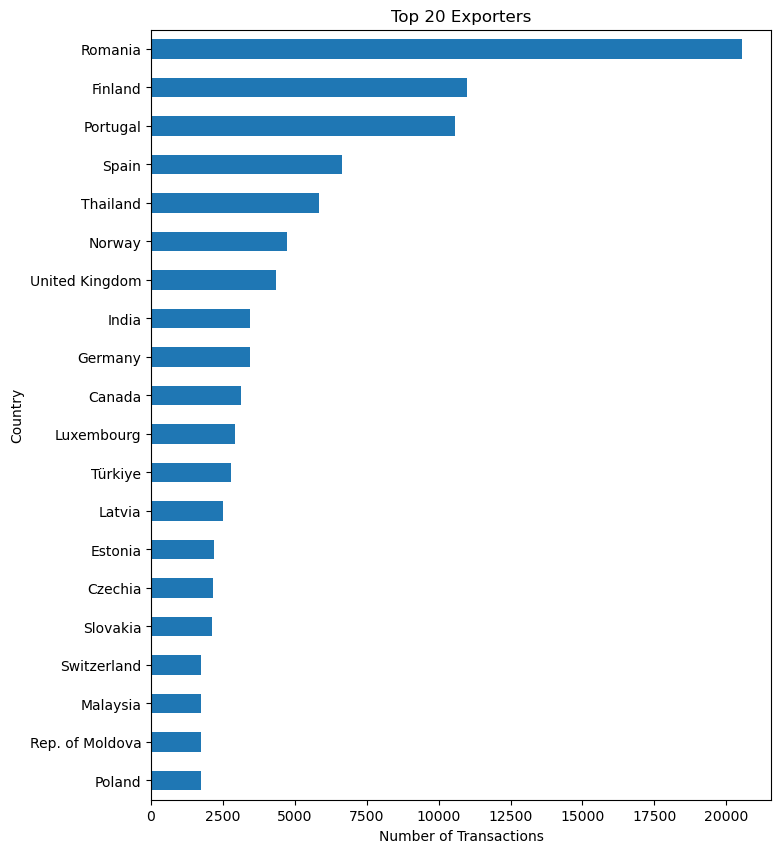

In [60]:
# From df_export
df_export['reporterDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Exporters")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

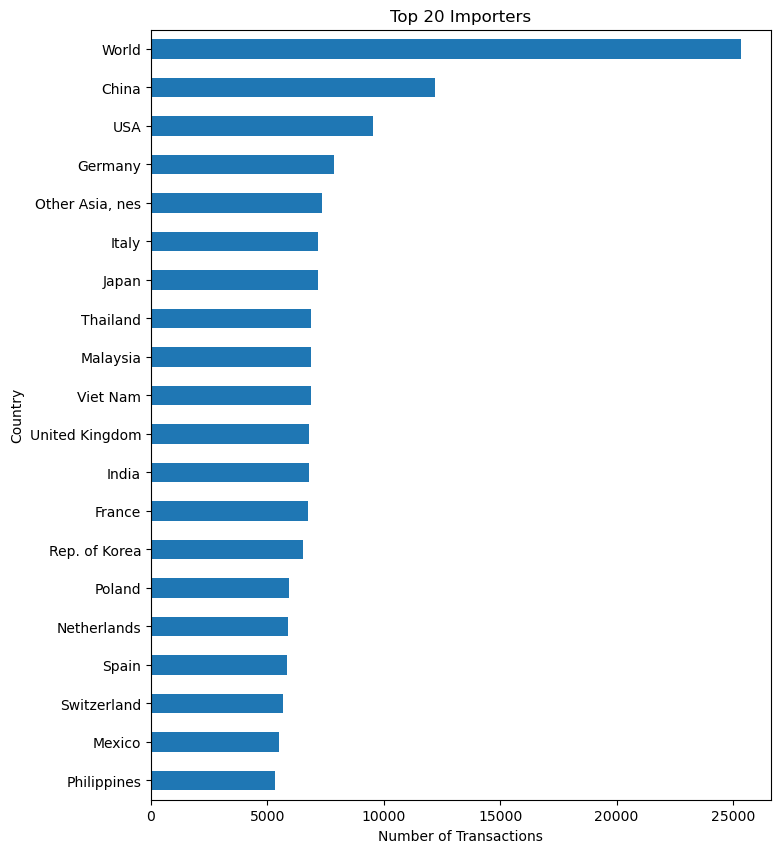

In [61]:
# From df_import
df_import['partnerDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

#### Importers

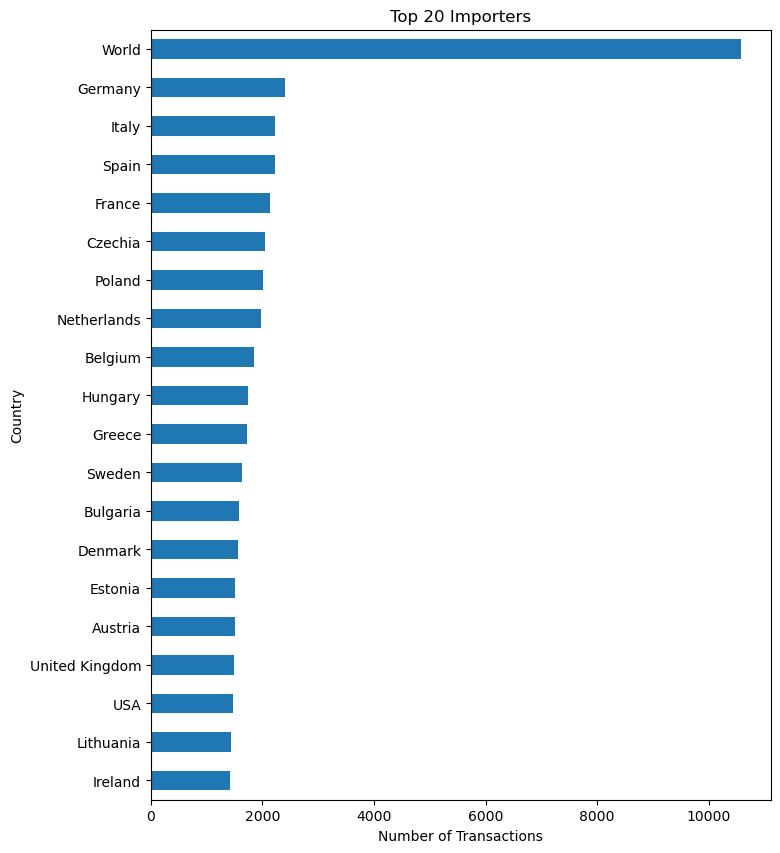

In [62]:
# From df_export
df_export['partnerDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

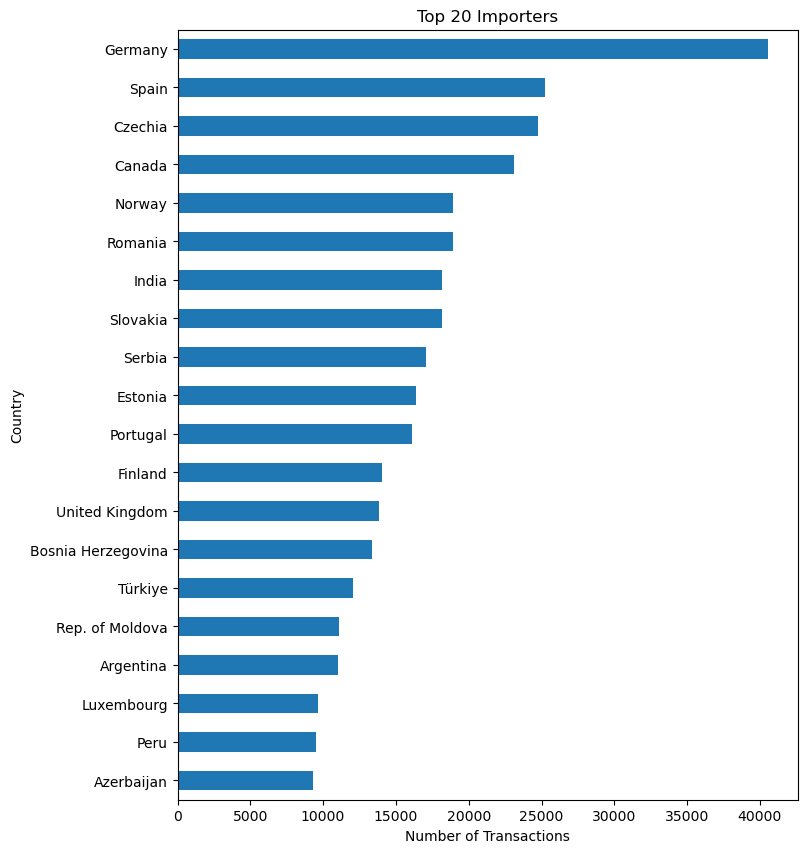

In [63]:
# From df_import
df_import['reporterDesc'].value_counts().head(20).plot(kind='barh', figsize=(8, 10))
plt.title("Top 20 Importers")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

#### Insight:
We can take a data either import or export from both export report or import report. However, we will have some aggregation data from the opposite report such as taking an export data from import report which exporter will be as 'partner' and the 'reporter' will be the import country. The reporter somehow create a aggregation data such as 'World' as their 'partner'. So we have to focus on the 'reporter' only to avoid aggregation data.

# Outlier Check

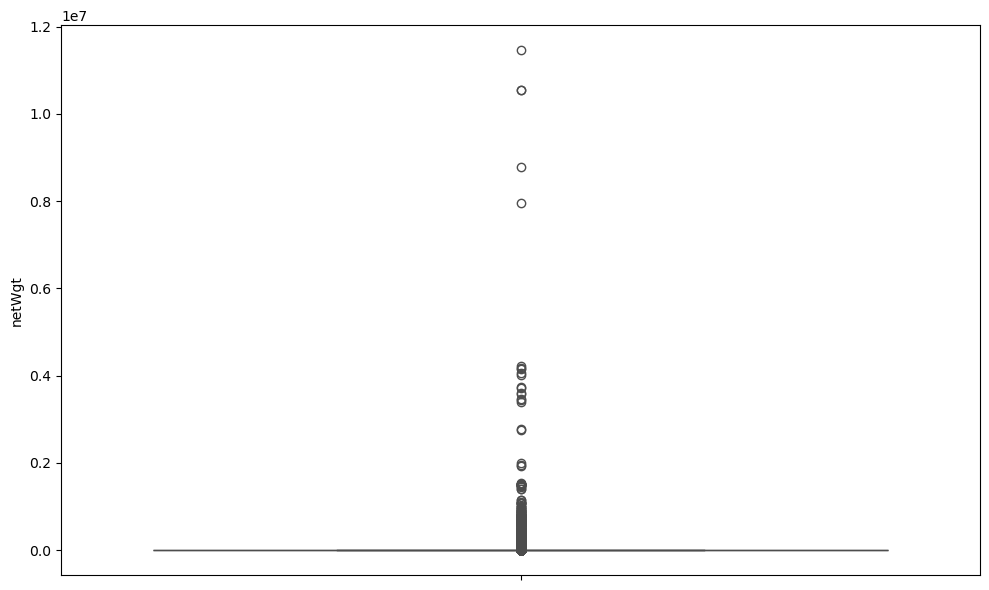

In [64]:
# Check outliers
numerical_columns = df_export.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 6))
for i in range(0, len(numerical_columns)):
    plt.subplot(1,len(numerical_columns), i+1)
    sns.boxplot(y=df_export[numerical_columns[i]], color='blue')
    plt.tight_layout()

Since the operations value is the part that has outliers, we will keep the outliers, to keep the original information.

# Export Data for PBI uses

In [ ]:
df_export.to_excel('df_export.xlsx', index=False)

In [ ]:
df_import.to_excel('df_import.xlsx', index=False)

## Data of the quantity

In [65]:
zero_counts = df_export.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
netWgt          0
dtype: int64


In [66]:
# Drop rows where 'qty' is zero in df_export
df_export_qty = df_export[df_export['qty'] != 0].reset_index(drop=True)
df_export_qty.head()

,reporterCode,reporterDesc,partnerCode,partnerDesc,period,flowCode,flowDesc,cmdCode,cmdDesc,qty,fobvalue,netWgt
0,36,Australia,238,Falkland Isds (Malvinas),202501,X,Export,TOTAL,All Commodities,0,1289.771,2318.376691
1,36,Australia,84,Belize,202501,X,Export,TOTAL,All Commodities,0,2085.918,2318.376691
2,36,Australia,0,World,202501,X,Export,TOTAL,All Commodities,0,25975646838.107,2318.376691
3,36,Australia,140,Central African Rep.,202501,X,Export,TOTAL,All Commodities,0,379.71,2318.376691
4,36,Australia,0,World,202501,X,Export,8542,Electronic integrated circuits,0,7397398.731,2318.376691


In [67]:
zero_counts = df_export_qty.apply(lambda x: (x == 0).sum())
print(zero_counts)

reporterCode    0
reporterDesc    0
partnerCode     0
partnerDesc     0
period          0
flowCode        0
flowDesc        0
cmdCode         0
cmdDesc         0
qty             0
fobvalue        0
netWgt          0
dtype: int64


In [68]:
df_export_qty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139808 entries, 0 to 139807
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   reporterCode  139808 non-null  object 
 1   reporterDesc  139808 non-null  object 
 2   partnerCode   139808 non-null  object 
 3   partnerDesc   139808 non-null  object 
 4   period        139808 non-null  object 
 5   flowCode      139808 non-null  object 
 6   flowDesc      139808 non-null  object 
 7   cmdCode       139808 non-null  object 
 8   cmdDesc       139808 non-null  object 
 9   qty           139808 non-null  object 
 10  fobvalue      139808 non-null  object 
 11  netWgt        139808 non-null  float64
dtypes: float64(1), object(11)
memory usage: 12.8+ MB


In [69]:
df_export_qty.to_excel('df_export_qty.xlsx', index=False)

KeyboardInterrupt: 

# Data Manipulation

In [71]:
# Select only columns with float or int data types from df_copy_clean
numeric_df = df_export.select_dtypes(include=['float64', 'int64'])
numeric_df.head()

,netWgt
0,2318.376691
1,2318.376691
2,2318.376691
3,2318.376691
4,2318.376691


In [72]:
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

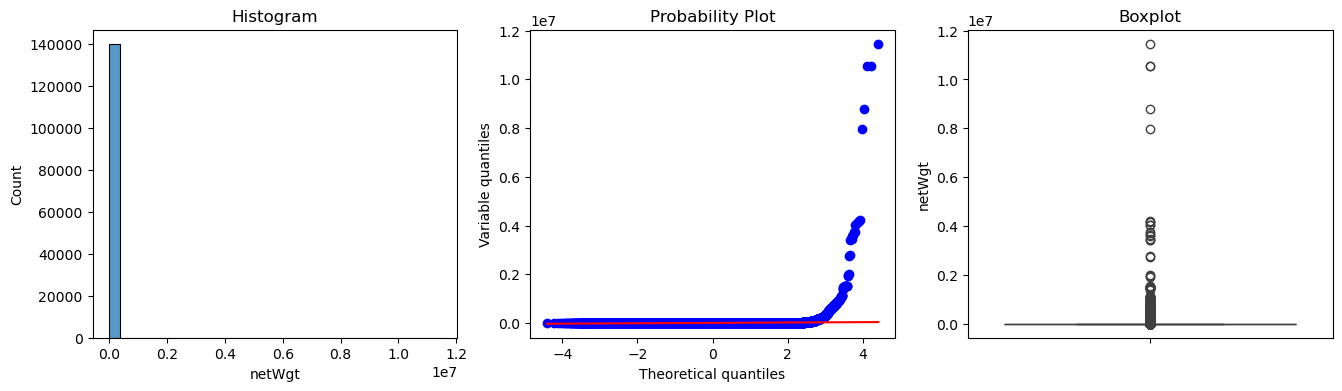

In [73]:
for col in numeric_df:
    check_plot(numeric_df, col)

There is nothing to conclude yet here.

In [74]:
# Convert fobvalue to numeric before aggregation
df_export['fobvalue'] = pd.to_numeric(df_export['fobvalue'], errors='coerce')
top_countries = df_export.groupby('reporterDesc')['fobvalue'].mean().sort_values(ascending=False).reset_index()
top_countries.head(10)

,reporterDesc,fobvalue
0,China,1.331227e+10
1,Rep. of Korea,1.001577e+10
2,Singapore,9.308068e+09
3,USA,1.190921e+09
4,Germany,8.492807e+08
5,Mexico,7.443323e+08
6,"China, Hong Kong SAR",6.756542e+08
7,France,5.123834e+08
8,Japan,4.922762e+08
9,Italy,3.866849e+08


/var/folders/1q/y9bbyxz522bd8ynv6y9yhwx00000gn/T/ipykernel_61213/1022818561.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries.head(10), x='fobvalue', y='reporterDesc', palette='viridis')


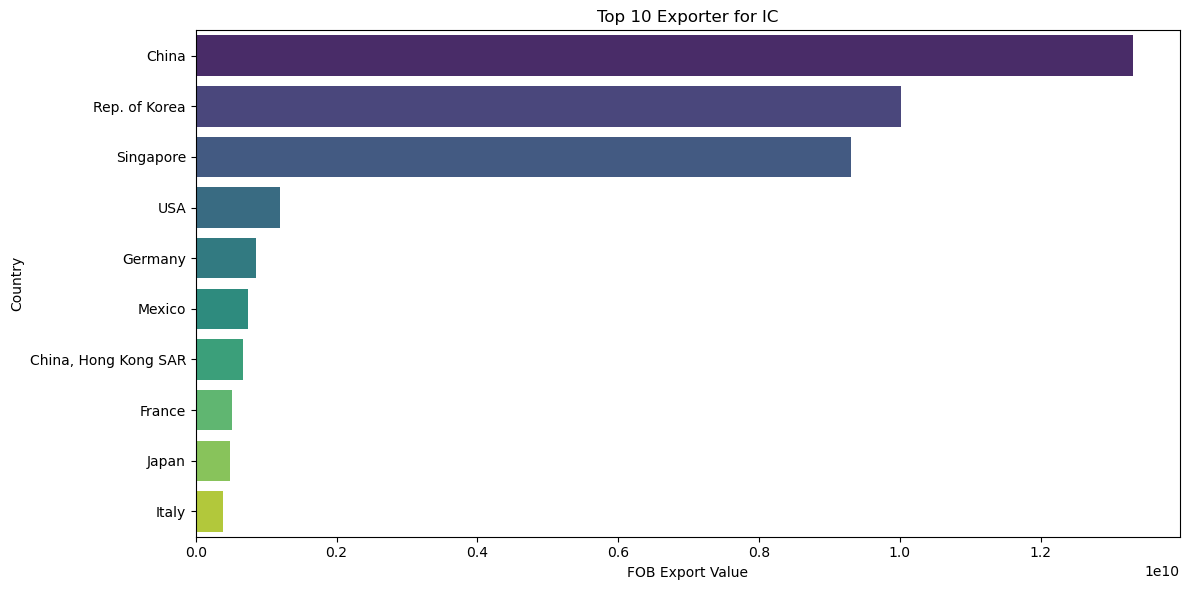

In [76]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries.head(10), x='fobvalue', y='reporterDesc', palette='viridis')
plt.title('Top 10 Exporter for IC')
plt.xlabel('FOB Export Value')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

<Axes: xlabel='period'>

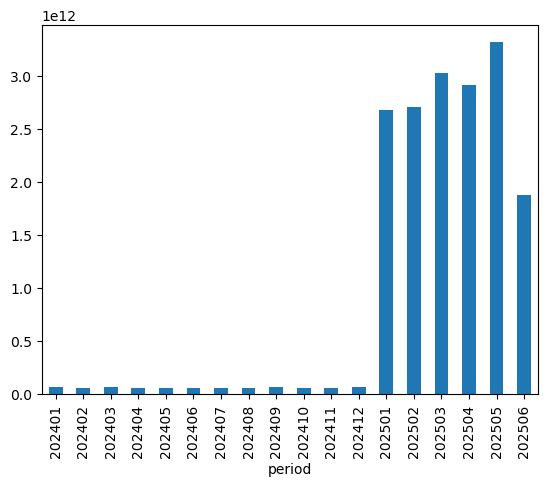

In [78]:
df_export.groupby(['period'])['fobvalue'].sum().plot(kind='bar')

In [ ]:
# a. Trend analysis over time
trend_df = df_export.groupby("refMonth")["fobvalue"].sum().reset_index()
trend_df

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=trend_df, x='refMonth', y='fobvalue', marker='o')
plt.title('FOB Export Value Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Total FOB Export Value')
plt.grid(True)
plt.show()

In [ ]:
# Calculate export value per kg
df_export["value_per_kg"] = df_export["fobvalue"] / df_export["netWgt"]

In [ ]:
# b. Avg export value/kg by country
value_per_kg_df = df_export.groupby("reporterDesc")["value_per_kg"].mean().reset_index()
value_per_kg_df = value_per_kg_df.sort_values(by="value_per_kg", ascending=False).head(20)
value_per_kg_df

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')
plt.title('Top 20 Countries by Average Export Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [ ]:
importer_value_per_kg_df = df_export.groupby("partnerDesc").agg(
    total_fobvalue=("fobvalue", "sum"),
    total_netwgt=("netWgt", "sum")
).reset_index()

In [ ]:
# Calculate value per kg
importer_value_per_kg_df["value_per_kg"] = (
    importer_value_per_kg_df["total_fobvalue"] / importer_value_per_kg_df["total_netwgt"]
)
importer_value_per_kg_df = importer_value_per_kg_df.sort_values(by="value_per_kg", ascending=False).head(20)


In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=importer_value_per_kg_df, x='value_per_kg', y='partnerDesc', palette='mako')
plt.title('Top 20 Countries by Average Import Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()

plt.figure(figsize=(8, 6))
sns.barplot(data=value_per_kg_df, x='value_per_kg', y='reporterDesc', palette='mako')
plt.title('Top 20 Countries by Average Export Value per Kg')
plt.xlabel('Average FOB Value per Kg')
plt.ylabel('Country')
plt.tight_layout()

plt.show()

In [ ]:
# Apply threshold: remove countries with too small total weight (e.g., <100kg)
filtered_df = importer_value_per_kg_df[importer_value_per_kg_df["total_netwgt"] > 100]

# Get top 20 by FOB value
top_importers_filtered = filtered_df.sort_values(by="value_per_kg", ascending=False).head(20)

# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=top_importers_filtered, y="partnerDesc", x="value_per_kg", palette="viridis")
plt.title("Top 20 Countries by Avg Import Value per Kg (Min 100kg Total Weight)")
plt.xlabel("Average FOB Value per Kg (USD/kg)")
plt.ylabel("Country")
plt.show()


Move to PBI to make a complete visualization, and conclusion. Business recommendation is in Powerpoint.

In [ ]:
# Top exporters by FOB
top_exp = (df_copy_export.groupby('reporterDesc')['fobvalue']
                 .sum().sort_values(ascending=False).head(10))

# Weighted $/kg with a weight floor (e.g., 1,000 kg)
g = df_copy_export[(df_copy_export['netWgt'] > 0) & (df_copy_export['fobvalue'] > 0)] \
        .groupby('reporterDesc').agg(val=('fobvalue','sum'),
                                     wgt=('netWgt','sum'))
g['usd_per_kg'] = g['val'] / g['wgt']
price_rank = g[g['wgt'] >= 1000].sort_values('usd_per_kg', ascending=False).head(10)

In [ ]:
# Plot
plt.figure(figsize=(10, 7))
sns.barplot(data=price_rank, x='usd_per_kg', y=price_rank.index, palette="viridis")
plt.title("Top 10 Countries by Avg Export Value per Kg (Min 1000kg Total Weight)")
plt.xlabel("Average FOB Value per Kg (USD/kg)")
plt.ylabel("Country")
plt.legend()
print("x value (usd_per_kg):")
print(price_rank['usd_per_kg'])
plt.show()